# 6-1 Bitcoin Hash Rate

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/6-1_hash_rate.ipynb)

**對應影片**：第 6 章 單元 6-1【基本面策略】Bitcoin Hash Rate

**和影片的差異**

- 影片使用 Glassnode API，但 Glassnode 已經不提供免費 API（舊金鑰會回覆「需要 API addon」）。本單元改用免金鑰的公開資料：算力改用 Coin Metrics 社群版的 `HashRate`（每日平均，TH/s）。
- `onchain.align(series, index)` 取代影片裡自己寫的 `get_glassnode` 對齊步驟：日資料要等當天結束才知道，所以先往後移一天，再對齊到 K 線時間，避免「偷看未來」。
- 資料改從 Binance 公開資料端點下載（`data-api.binance.vision`，不需金鑰、Colab 可用），`get_all_binance` 的寫法和影片一樣。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import finlab_crypto

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '1d')

BTCUSDT 1d: 3326 candles (2017-08-17 ~ 2026-09-24 00:00 UTC)


# 比特幣算力（Hash Rate）

資料來源：[Coin Metrics Community Data](https://coinmetrics.io/community-network-data/)（CC BY-NC 4.0，公開分享結果時請註明）。

<Axes: xlabel='timestamp'>

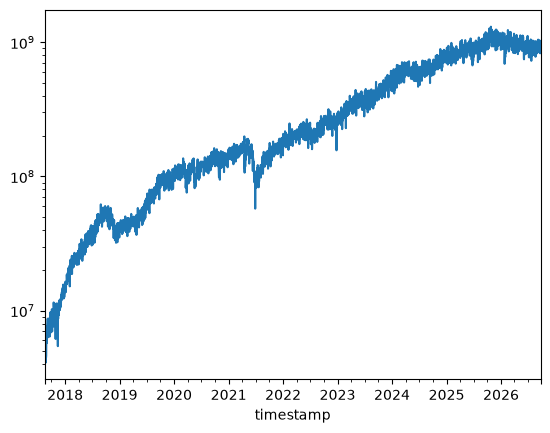

In [3]:
from finlab_crypto import onchain

hash_rate = onchain.coinmetrics(['HashRate']).HashRate
hash_rate = onchain.align(hash_rate, ohlcv.index)
hash_rate.plot(logy=True)

# 礦工投降（Miner capitulation）

算力 30 日均線跌破 60 日均線，代表有礦工關機（挖礦不划算）；重新站回 60 日均線時，
代表礦工投降結束，歷史上常是不錯的買點。

<Axes: xlabel='timestamp'>

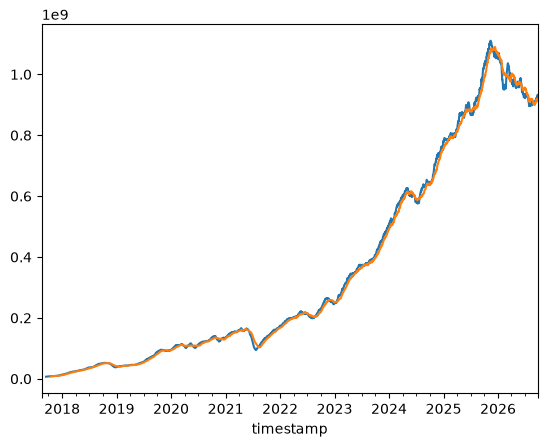

In [4]:
hash_rate_ma30 = hash_rate.rolling(30).mean()
hash_rate_ma60 = hash_rate.rolling(60).mean()
hash_rate_ma30.plot()
hash_rate_ma60.plot()

<Axes: >

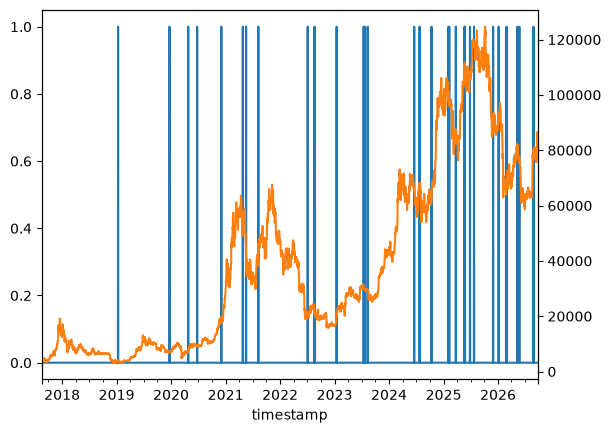

In [5]:
# crossover = True 的那天就是買進訊號
crossover = (hash_rate_ma30 > hash_rate_ma60) & (hash_rate_ma30.shift() < hash_rate_ma60.shift())
crossover.astype(int).plot()
ohlcv.close.plot(secondary_y=True)

# 統計分析：訊號出現後 1 ~ 180 天的價格變化

[transpose](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transpose.html) 把表格的列與欄對調。

In [6]:
import pandas as pd

HOLDING_DAYS = range(1, 181)

results = {}
for d in HOLDING_DAYS:
    # 訊號出現 d 天後的收盤價；shift 產生的空值補 False
    results[d] = pd.Series(ohlcv.close[crossover.shift(d, fill_value=False)].values)

# 每一列是一次訊號；除以第 1 天的價格做標準化，再轉置讓每一欄是一次訊號
results = pd.DataFrame(results)
results = results.div(results[1], axis=0).transpose()
results

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.970328,0.991620,1.010597,0.990564,1.026656,0.996987,1.104566,0.985549,1.051568,0.994619,...,1.004134,1.003950,1.009880,1.002599,0.954914,0.974572,0.982130,0.985208,0.981997,1.004934
3,1.011990,0.984631,1.005964,0.974324,1.038009,0.973515,1.015315,0.983949,1.050098,1.000628,...,1.015709,0.999394,0.998599,1.015315,1.010158,0.971754,1.027724,1.007273,0.962847,0.997895
4,0.991608,0.984271,1.141097,0.985606,1.027687,1.048758,1.020704,0.959908,1.049956,0.993143,...,1.019722,0.988786,0.984942,1.003809,1.033975,0.966861,1.020377,0.982718,0.952090,1.009447
5,1.002431,0.991479,1.120485,0.993845,0.982499,1.050687,0.944540,1.033438,1.014489,1.002019,...,1.015094,0.968676,1.014472,1.002861,1.019014,0.965404,1.085012,0.970729,0.950063,0.994773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,3.141524,1.288220,1.495254,2.464694,1.912198,1.168484,1.768391,0.831656,0.804654,1.012453,...,0.881434,0.864751,0.823519,0.812409,0.852866,0.625344,1.150831,NaN,NaN,NaN
177,3.183317,1.301828,1.527534,2.498234,1.855452,1.199765,1.765443,0.836578,0.808843,1.012008,...,0.890773,0.845978,0.826296,0.808981,0.855711,0.640270,1.160672,NaN,NaN,NaN
178,3.415617,1.293566,1.548139,2.575451,1.911007,1.130538,1.747672,0.797700,0.807580,1.031802,...,0.878335,0.852819,0.825941,0.796443,0.840306,0.656654,1.179467,NaN,NaN,NaN
179,3.500685,1.282794,1.661354,2.535872,1.997468,1.103182,1.754697,0.806678,0.804415,1.130530,...,0.859268,0.839921,0.815365,0.787583,0.823919,0.667569,1.172694,NaN,NaN,NaN


<Axes: >

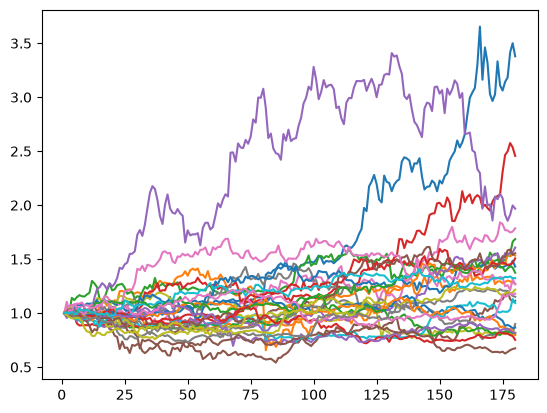

In [7]:
results.plot(legend=False)

In [8]:
# 選幾個持有天數來看
results.loc[[1, 30, 60, 90, 180]]

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
30,1.027052,1.193921,1.156926,1.031170,1.725332,0.713334,1.038236,1.013195,1.100098,0.908039,...,0.951562,0.966329,1.112946,0.981497,0.965440,0.780452,0.985631,0.764069,0.811342,NaN
60,1.083614,1.311508,1.208419,1.259327,1.797610,0.574138,0.859089,1.162838,0.964375,0.888842,...,1.093759,1.089463,1.041627,0.957800,0.988269,0.726565,1.139899,0.796996,0.841920,NaN
90,1.400276,0.845552,1.239786,1.138399,2.699623,0.643151,1.251054,1.328997,0.954512,0.776202,...,1.064788,1.072766,1.015822,0.914578,0.728996,0.736381,1.099208,0.806186,0.996805,NaN
180,3.379272,1.272395,1.685734,2.456320,1.967403,1.114062,1.785744,0.898837,0.808030,1.093054,...,0.866216,0.794806,0.817074,0.751844,0.814713,0.673551,1.179930,NaN,NaN,NaN
